# Per-cluster eigen decomposition of SEAM attribution maps

For a single reference sequence (default **peak84030**) we take every available SEAM run
(different library sizes / k-means cluster counts) and, for the **WT cluster** of each run,
treat the per-sequence SEAM attribution maps as observations:

- each member sequence of the cluster = one observation
- each (position x channel) = a feature (200 x 4 = 800 features)

We decompose the stacked maps **without observation-centering** (the attribution origin is a
meaningful reference, so the shared consensus map is signal — see the methods cell below).
Outputs:

1. **cluster cleanliness** = mode-1 variance fraction for every SEAM run of the ref seq
   (near 1 = every member shares one consensus map)
2. the **consensus mode (mode 1)** rendered as a sequence logo per run, plus **modes 1-3**
   (consensus + leading departures) for one focal run

In [73]:
import numpy as np, matplotlib.pyplot as plt, h5py, sys
from pathlib import Path

# Pablo's fast_logo renderer for attribution (L,4) logos
sys.path.insert(0, "/grid/koo/home/pmantill/projects/EigenMaps/eigen-interactions")
from fast_logo import fast_logo

R = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq")
OUT = Path("/grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results")

REF_SEQ = "peak26256"     # single reference sequence; all SEAM runs below are for this seq

# ---- discover every SEAM run available for REF_SEQ -------------------------------------
# a "run" = a foregrounds* clustering dir that has REF_SEQ + its matching library/ISM store.
# dir prefix -> library: 100k/_200k/_300k are @10% mut; _mut5 / _mut5_200k / _mut5_300k are @5%.
# check the most specific (mut5_200k/300k) prefixes first so they don't fall through to _mut5 / _200k.
def lib_suffix(fg_name):
    if fg_name.startswith("foregrounds_mut5_200k"): return "_mut5_200k"   # 200k @5%
    if fg_name.startswith("foregrounds_mut5_300k"): return "_mut5_300k"   # 300k @5%
    if fg_name.startswith("foregrounds_mut5"):      return "_mut5"        # 100k @5%
    if fg_name.startswith("foregrounds_200k"):      return "_200k"        # 200k @10%
    if fg_name.startswith("foregrounds_300k"):      return "_300k"        # 300k @10%
    return ""                                                             # 100k @10%
LIB_LABEL = {"": "100k", "_200k": "200k", "_300k": "300k",
             "_mut5": "mut5", "_mut5_200k": "mut5-200k", "_mut5_300k": "mut5-300k"}

runs = []
for fg in sorted(p.name for p in R.glob("foregrounds*") if p.is_dir()):
    fg_dir = R / fg / REF_SEQ
    suf    = lib_suffix(fg)
    ism_h5 = R / f"ism{suf}" / f"{REF_SEQ}.h5"
    if not (fg_dir / "cluster_labels.npy").exists() or not ism_h5.exists():
        continue
    labels   = np.load(fg_dir / "cluster_labels.npy")
    lib_size = LIB_LABEL[suf]
    runs.append(dict(fg_name=fg, fg_dir=fg_dir, ism_h5=ism_h5, suffix=suf,
                     lib_size=lib_size, lib_base=lib_size, n_seqs=len(labels),
                     n_clusters=len(np.unique(labels)),
                     label=f"{lib_size}_k{len(np.unique(labels))}"))

# ---- random-clustering control per (library x cluster count) ---------------------------
# for EVERY real run, shuffle that run's own library into its own number of clusters. The random
# "WT cluster" is a random subset of the SAME library -> the correct null cleanliness for that
# (library, K) combo (matters: the 5% library floors higher than 10%). seed = K, reproducible.
for r in list(runs):
    K, N = r["n_clusters"], r["n_seqs"]
    rl = np.random.default_rng(K).integers(0, K, size=N).astype(np.int32)
    runs.append(dict(fg_name="RANDOM", fg_dir=None, ism_h5=r["ism_h5"], suffix=r["suffix"],
                     lib_size=f"{r['lib_size']}·r", lib_base=r["lib_base"], n_seqs=N,
                     n_clusters=K, bg_src=r["fg_dir"],           # bg control uses its library's background
                     label=f"rand-{r['lib_size']}_k{K}", random_labels=rl))

n_rand = sum(r["fg_dir"] is None for r in runs)
print(f"{len(runs)} run(s) for {REF_SEQ} ({len(runs) - n_rand} real + {n_rand} matched random controls):")
for r in runs:
    print(f"  {r['label']:20s}  {r['fg_name']}  (ism{r['suffix']}/, {r['n_clusters']} clusters)")

38 run(s) for peak26256 (19 real + 19 matched random controls):
  100k_k50              foregrounds  (ism/, 50 clusters)
  200k_k100             foregrounds_200k  (ism_200k/, 100 clusters)
  200k_k150             foregrounds_200k_kmeans150  (ism_200k/, 150 clusters)
  200k_k200             foregrounds_200k_kmeans200  (ism_200k/, 200 clusters)
  200k_k300             foregrounds_200k_kmeans300  (ism_200k/, 300 clusters)
  300k_k50              foregrounds_300k  (ism_300k/, 50 clusters)
  300k_k100             foregrounds_300k_kmeans100  (ism_300k/, 100 clusters)
  300k_k200             foregrounds_300k_kmeans200  (ism_300k/, 200 clusters)
  300k_k300             foregrounds_300k_kmeans300  (ism_300k/, 300 clusters)
  300k_k400             foregrounds_300k_kmeans400  (ism_300k/, 400 clusters)
  100k_k100             foregrounds_kmeans100  (ism/, 100 clusters)
  100k_k200             foregrounds_kmeans200  (ism/, 200 clusters)
  100k_k250             foregrounds_kmeans250  (ism/, 250 clus

## Eigen decomposition per WT cluster (uncentered)

For each run, the WT reference is row 0 of the mutagenesis library, so its cluster is
`cluster_labels[0]`. We pull the ISM-centered attribution maps of every member of that
cluster and flatten to `(n_members, 800)`.

We deliberately **do not observation-center** (no mean subtraction across members): the
attribution origin (0 = no contribution) is a meaningful physical reference, so the shared
cluster-mean map is signal, not an offset to remove. We take the SVD of the raw stacked
maps. **Mode 1 is the shared consensus map**, and its variance fraction
`S[0]**2 / sum(S**2)` is a **cluster-cleanliness / collinearity score** — high (near 1)
means every member tells the same story. Modes 2, 3, ... are the leading *departures* from
that consensus (they equal the mean-centered PCA modes). Mode signs are arbitrary; we orient
each toward the WT cluster-average map.

In [74]:
import pickle

# per-run cache keyed by run label: only runs missing from the cache are computed (each SVD
# reloads big ISM slices), so adding a new run computes just that one.
CACHE     = OUT / f"{REF_SEQ}_decomp.pkl"
RECOMPUTE = False

def _orient(vec, ref):
    # deterministic sign: align with the cluster-mean map when they overlap, else make the peak positive
    s = float(np.sum(vec * ref))
    if abs(s) > 1e-8:
        return vec if s >= 0 else -vec
    return vec if vec.flat[np.argmax(np.abs(vec))] >= 0 else -vec

def _decomp(r):
    labels = r.get("random_labels")                          # random control carries its own labels
    if labels is None:
        labels = np.load(r["fg_dir"] / "cluster_labels.npy")
    wt_cluster = int(labels[0]); members = np.where(labels == wt_cluster)[0]
    with h5py.File(r["ism_h5"]) as f:
        maps = f["ism_centered"][members]                    # (M, 200, 4)
    M = len(members)
    avg_map = maps.mean(0).astype(np.float32)                # average WT-cluster map (raw)
    X = maps.reshape(M, -1).astype(np.float64)               # uncentered: shared mean counts as variance
    _, S, Vt = np.linalg.svd(X, full_matrices=False)
    frac = S ** 2 / np.sum(S ** 2)
    modes = [_orient(Vt[k].reshape(200, 4), avg_map) for k in range(3)]
    return dict(label=r["label"], fg_name=r["fg_name"], lib_base=r["lib_base"], lib_size=r["lib_size"],
                wt_cluster=wt_cluster, n_members=M, n_clusters=r["n_clusters"],
                cleanliness=float(frac[0]), frac=frac[:3].astype(float), modes=modes,
                avg_map=avg_map, is_random=r["fg_dir"] is None)

cache = {} if (RECOMPUTE or not CACHE.exists()) else pickle.load(open(CACHE, "rb"))
if isinstance(cache, list):                                  # migrate old list-format cache -> dict by label
    cache = {d["label"]: d for d in cache}

# backfill avg_map for real runs cached before that field existed (cheap npy read, no ISM reload)
n_bf = 0
for r in runs:
    d = cache.get(r["label"])
    if d is not None and "avg_map" not in d and r["fg_dir"] is not None:
        d["avg_map"] = np.load(r["fg_dir"] / "ref_cluster_avg.npy").astype(np.float32); n_bf += 1
# evict entries still missing avg_map (e.g. random controls cached before the field) -> recompute below
for lab in [l for l, d in list(cache.items()) if "avg_map" not in d]:
    del cache[lab]

n_new = 0
for r in runs:
    if r["label"] not in cache:
        cache[r["label"]] = _decomp(r); n_new += 1
        d = cache[r["label"]]
        print(f"computed {r['label']:20s}  ({d['n_members']:6d} seqs)  mode1={d['cleanliness']:.3f}")
if n_new or n_bf:
    pickle.dump(cache, open(CACHE, "wb"))
    print(f"cached {n_new} new + backfilled {n_bf} run(s) -> {CACHE.name}")
else:
    print(f"all {len(runs)} runs loaded from cache ({CACHE.name})")

results = sorted((cache[r["label"]] for r in runs), key=lambda d: (d["is_random"], d["label"]))

computed rand-100k_k50         (  1951 seqs)  mode1=0.555
computed rand-200k_k100        (  2048 seqs)  mode1=0.552
computed rand-200k_k150        (  1352 seqs)  mode1=0.555
computed rand-200k_k200        (  1031 seqs)  mode1=0.560
computed rand-200k_k300        (   685 seqs)  mode1=0.551
computed rand-300k_k50         (  5997 seqs)  mode1=0.547
computed rand-300k_k100        (  3081 seqs)  mode1=0.557
computed rand-300k_k200        (  1509 seqs)  mode1=0.554
computed rand-300k_k300        (   998 seqs)  mode1=0.558
computed rand-300k_k400        (   717 seqs)  mode1=0.550
computed rand-100k_k100        (  1016 seqs)  mode1=0.551
computed rand-100k_k200        (   499 seqs)  mode1=0.562
computed rand-100k_k250        (   391 seqs)  mode1=0.563
computed rand-100k_k300        (   325 seqs)  mode1=0.566
computed rand-100k_k350        (   279 seqs)  mode1=0.559
computed rand-100k_k400        (   247 seqs)  mode1=0.552
computed rand-mut5_k100        (  1016 seqs)  mode1=0.703
computed rand-

## 1. Cluster cleanliness (mode-1 variance fraction) across all SEAM runs

Uncentered mode-1 fraction: near 1 = every member shares the same consensus map (clean/tight
cluster); lower = variance splits into secondary modes (heterogeneous cluster).

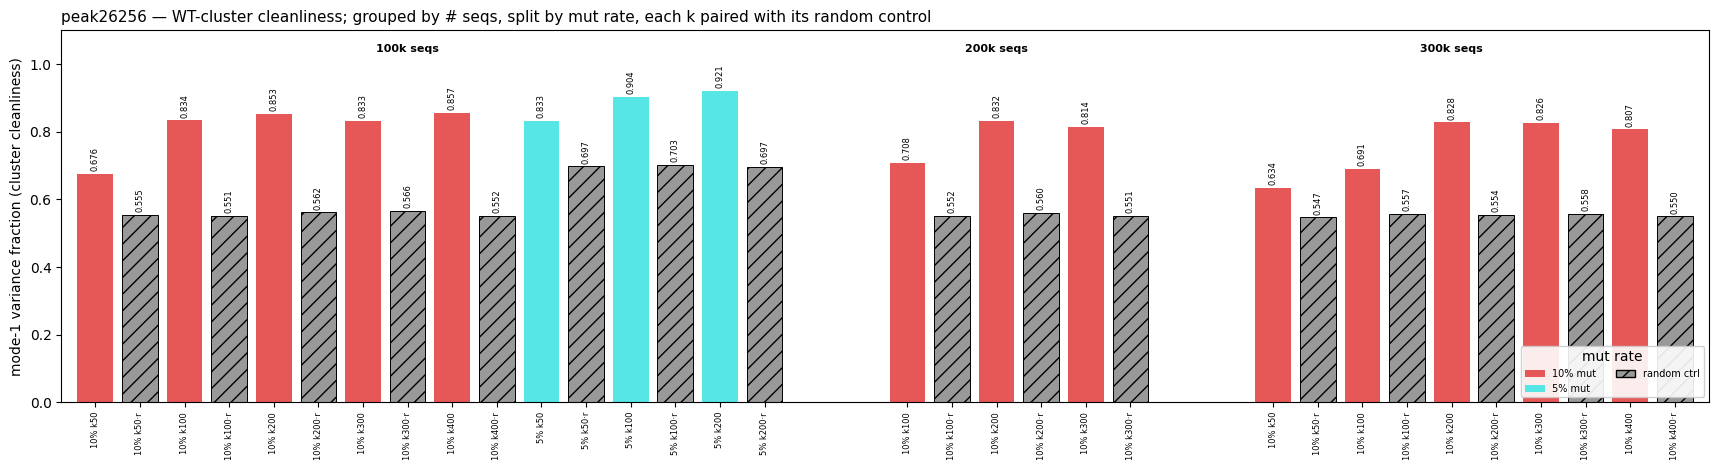

In [75]:
import colorsys
from matplotlib.patches import Patch

def kof(d):   return int(d["label"].split("_k")[-1])          # cluster count
def basel(d):                                                 # underlying library (real & its random share it)
    lib = d["label"].split("_k")[0]
    return lib[5:] if lib.startswith("rand-") else lib
NSEQ  = {"100k": 100, "200k": 200, "300k": 300, "mut5": 100, "mut5-200k": 200, "mut5-300k": 300}
def nseq(d):  return NSEQ[basel(d)]                           # library size = number of seqs (the group)
def mrate(d): return "5%" if basel(d).startswith("mut5") else "10%"   # mutagenesis rate (split within group)
MRANK = {"10%": 0, "5%": 1}

# drop singleton intermediate cluster counts (each exists for only one library -> no comparison value)
EXCLUDE_K = {150, 250, 350}

# group by # seqs (100k/200k/300k); within a group split by mut rate, then k, each real paired with its random
order = sorted((d for d in results if kof(d) not in EXCLUDE_K),
               key=lambda d: (nseq(d), MRANK[mrate(d)], kof(d), d["is_random"]))
rates  = sorted({mrate(d) for d in order}, key=lambda m: MRANK[m])
rcolor = {m: colorsys.hsv_to_rgb(i / max(len(rates), 2), 0.62, 0.90) for i, m in enumerate(rates)}
nseqs  = sorted({nseq(d) for d in order})

# x positions with a wide gap between seq-count groups
GAP = 2.2
xs, x, prev = [], 0, None
for d in order:
    if prev is not None and nseq(d) != prev: x += GAP
    xs.append(x); x += 1; prev = nseq(d)

fig, ax = plt.subplots(figsize=(max(8, 0.42 * x + 2), 4.8))
for xi, d in zip(xs, order):
    ax.bar(xi, d["cleanliness"], color="0.6" if d["is_random"] else rcolor[mrate(d)],
           hatch="//" if d["is_random"] else None,
           edgecolor="black" if d["is_random"] else "none", linewidth=0.7)
    ax.text(xi, d["cleanliness"] + 0.008, f"{d['cleanliness']:.3f}",
            ha="center", va="bottom", fontsize=6, rotation=90)

ax.set_xticks(xs)
ax.set_xticklabels([f"{mrate(d)} k{kof(d)}" + ("·r" if d["is_random"] else "") for d in order],
                   rotation=90, fontsize=6.0)
for s in nseqs:                                              # header centered over the REAL bars of each seq-count
    gx = [xi for xi, d in zip(xs, order) if not d["is_random"] and nseq(d) == s]
    ax.text(np.mean(gx), 1.03, f"{s}k seqs", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_ylabel("mode-1 variance fraction (cluster cleanliness)")
ax.set_ylim(0, 1.10)
ax.margins(x=0.01)
ax.legend(handles=[Patch(facecolor=rcolor[m], label=f"{m} mut") for m in rates] +
                  [Patch(facecolor="0.6", edgecolor="black", hatch="//", label="random ctrl")],
          title="mut rate", fontsize=7, ncol=2, loc="lower right", framealpha=0.9)
ax.set_title(f"{REF_SEQ} — WT-cluster cleanliness; grouped by # seqs, split by mut rate, each k paired with "
             f"its random control", loc="left", fontsize=11)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_cluster_cleanliness.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Consensus mode (mode 1) + average maps as logos

Each real run is drawn **side by side with its matched random control** (real left, control
right; singleton k's 150/250/350 excluded; rows ordered by library size then k). First the
mode-1 consensus eigenvector per run, then the raw average WT-cluster map per run. (The
background-subtracted foreground is in section 2b.)

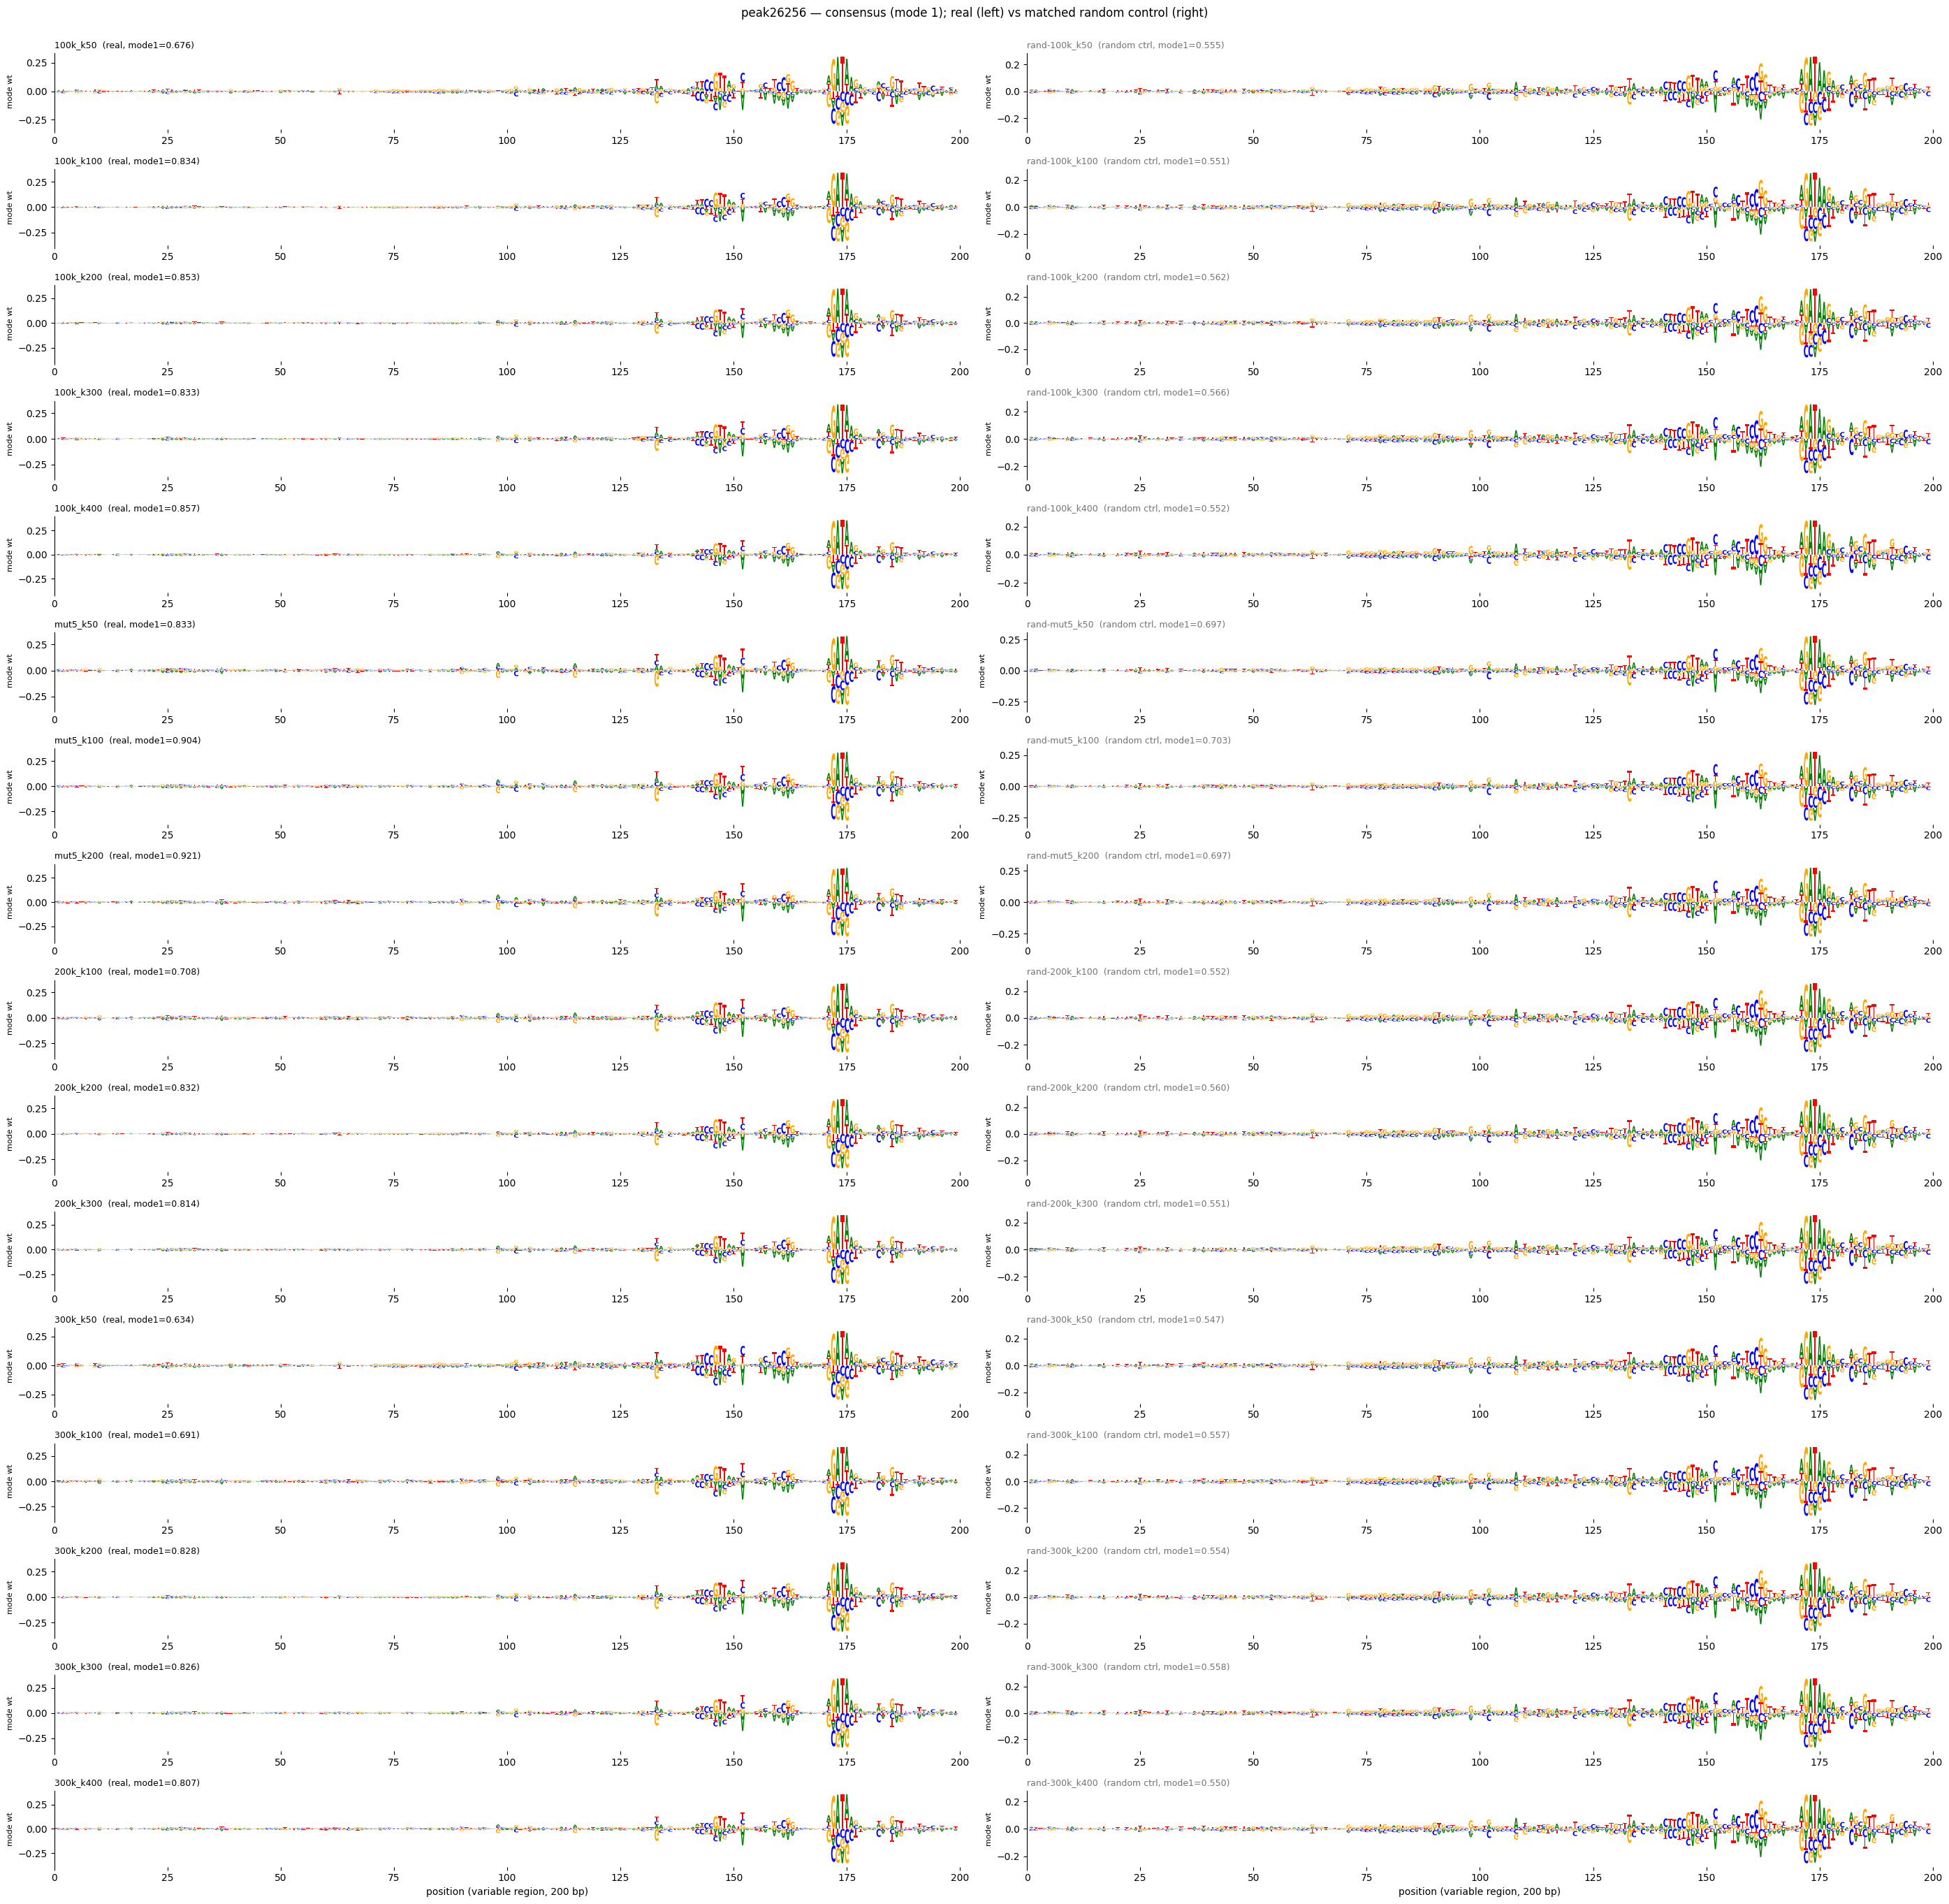

In [76]:
def kof(d):   return int(d["label"].split("_k")[-1])
def basel(d):
    lib = d["label"].split("_k")[0]
    return lib[5:] if lib.startswith("rand-") else lib
NSEQ = {"100k": 100, "200k": 200, "300k": 300, "mut5": 100, "mut5-200k": 200, "mut5-300k": 300}
EXCLUDE_K = {150, 250, 350}

# one row per real run (ordered by library size then k); real logo left, its matched random control right
bylabel = {d["label"]: d for d in results}
reals   = sorted((d for d in results if not d["is_random"] and kof(d) not in EXCLUDE_K),
                 key=lambda d: (NSEQ[basel(d)], basel(d), kof(d)))
pairs   = [(d, bylabel.get("rand-" + d["label"])) for d in reals]

n = len(pairs)
fig, axes = plt.subplots(n, 2, figsize=(28, 1.7 * n), sharex=False, squeeze=False)   # each on its own scale
for (dl, dr), (axL, axR) in zip(pairs, axes):
    fast_logo(dl["modes"][0], axL)                             # real mode-1 eigenvector (consensus direction)
    axL.set_title(f"{dl['label']}  (real, mode1={dl['cleanliness']:.3f})", loc="left", fontsize=9)
    if dr is not None:
        fast_logo(dr["modes"][0], axR)                         # matched random control
        axR.set_title(f"{dr['label']}  (random ctrl, mode1={dr['cleanliness']:.3f})",
                      loc="left", fontsize=9, color="0.45")
    else:
        axR.axis("off")
    for ax in (axL, axR):
        ax.set_ylabel("mode wt", fontsize=8)
        ax.set_xlim(0, 200)
        for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("position (variable region, 200 bp)")
fig.suptitle(f"{REF_SEQ} — consensus (mode 1); real (left) vs matched random control (right)", y=1.0, fontsize=12)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_consensus_mode_logos.png", dpi=150, bbox_inches="tight")
plt.show()

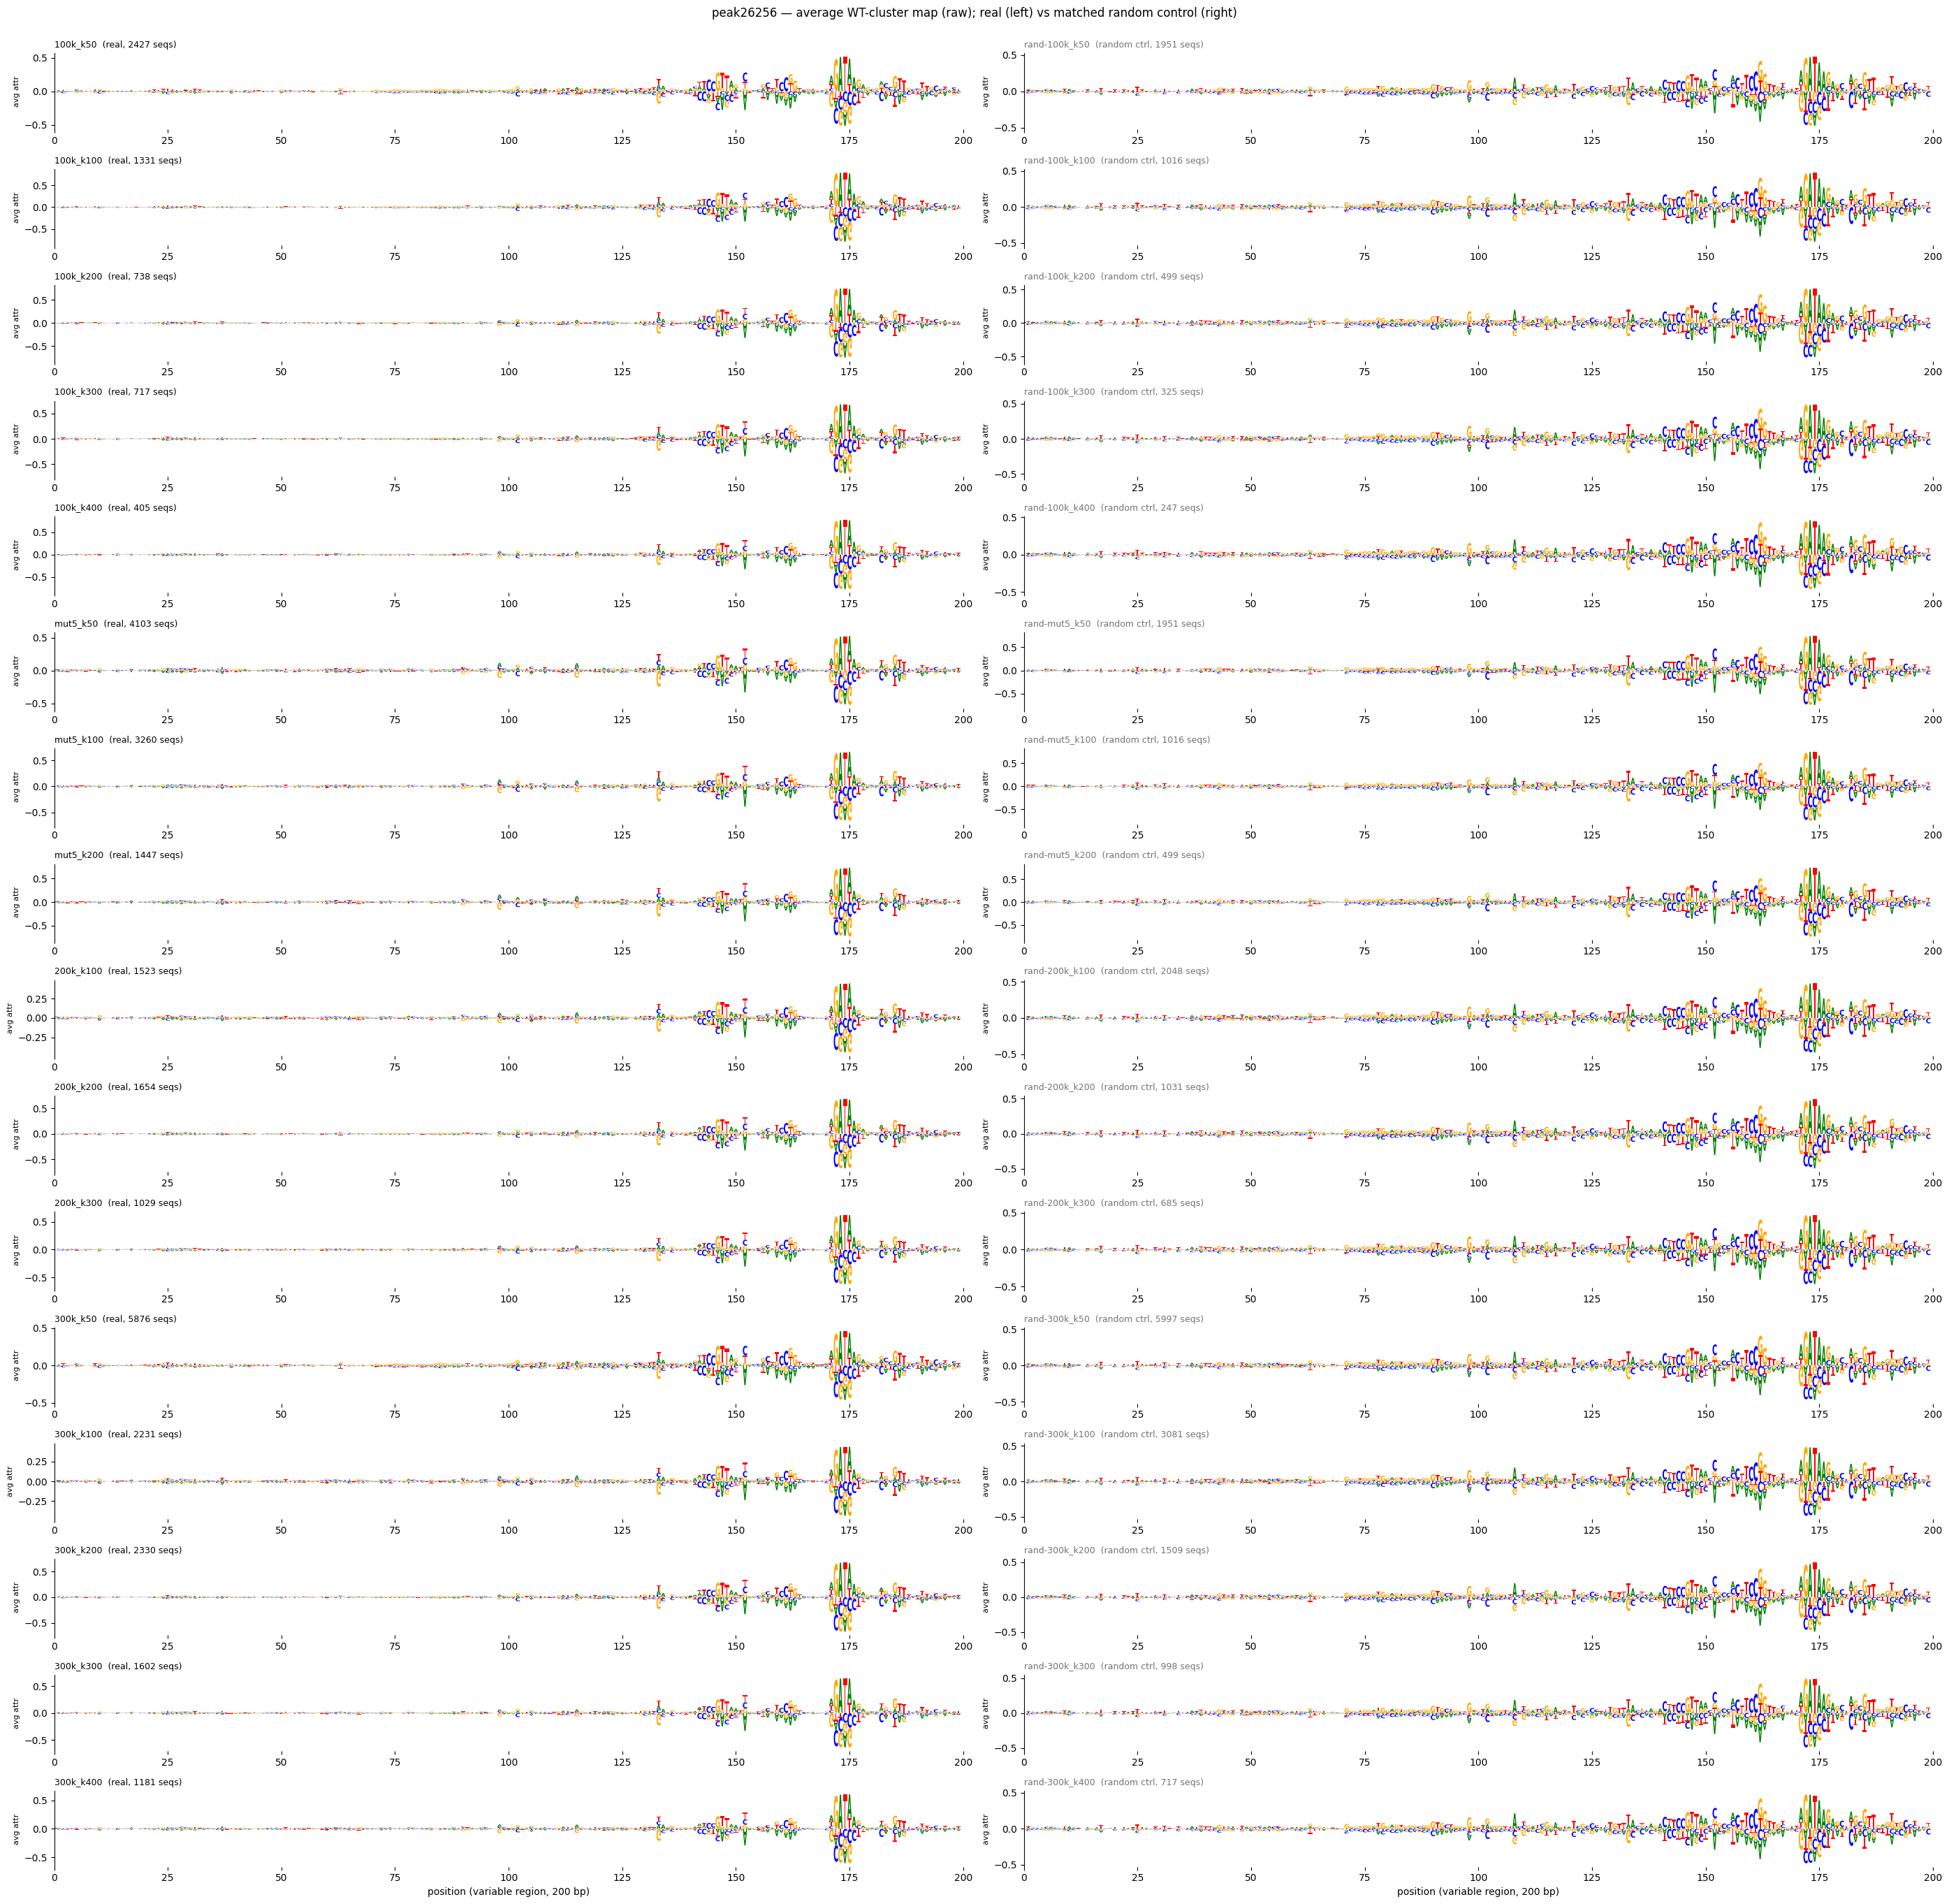

In [77]:
# per-run AVERAGE WT-cluster map (raw, no bg subtraction); real logo left, its random control right
def kof(d):   return int(d["label"].split("_k")[-1])
def basel(d):
    lib = d["label"].split("_k")[0]
    return lib[5:] if lib.startswith("rand-") else lib
NSEQ = {"100k": 100, "200k": 200, "300k": 300, "mut5": 100, "mut5-200k": 200, "mut5-300k": 300}
EXCLUDE_K = {150, 250, 350}

bylabel = {d["label"]: d for d in results}
reals   = sorted((d for d in results if not d["is_random"] and kof(d) not in EXCLUDE_K),
                 key=lambda d: (NSEQ[basel(d)], basel(d), kof(d)))
pairs   = [(d, bylabel.get("rand-" + d["label"])) for d in reals]

n = len(pairs)
fig, axes = plt.subplots(n, 2, figsize=(28, 1.7 * n), sharex=False, squeeze=False)   # each on its own scale
for (dl, dr), (axL, axR) in zip(pairs, axes):
    fast_logo(dl["avg_map"], axL)                              # real average WT-cluster map (raw)
    axL.set_title(f"{dl['label']}  (real, {dl['n_members']} seqs)", loc="left", fontsize=9)
    if dr is not None:
        fast_logo(dr["avg_map"], axR)                          # matched random control
        axR.set_title(f"{dr['label']}  (random ctrl, {dr['n_members']} seqs)",
                      loc="left", fontsize=9, color="0.45")
    else:
        axR.axis("off")
    for ax in (axL, axR):
        ax.set_ylabel("avg attr", fontsize=8)
        ax.set_xlim(0, 200)
        for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("position (variable region, 200 bp)")
fig.suptitle(f"{REF_SEQ} — average WT-cluster map (raw); real (left) vs matched random control (right)",
             y=1.0, fontsize=12)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_avg_cluster_map_logos.png", dpi=150, bbox_inches="tight")
plt.show()

best run: mut5_k200  (foregrounds_mut5_kmeans200, cleanliness=0.921)


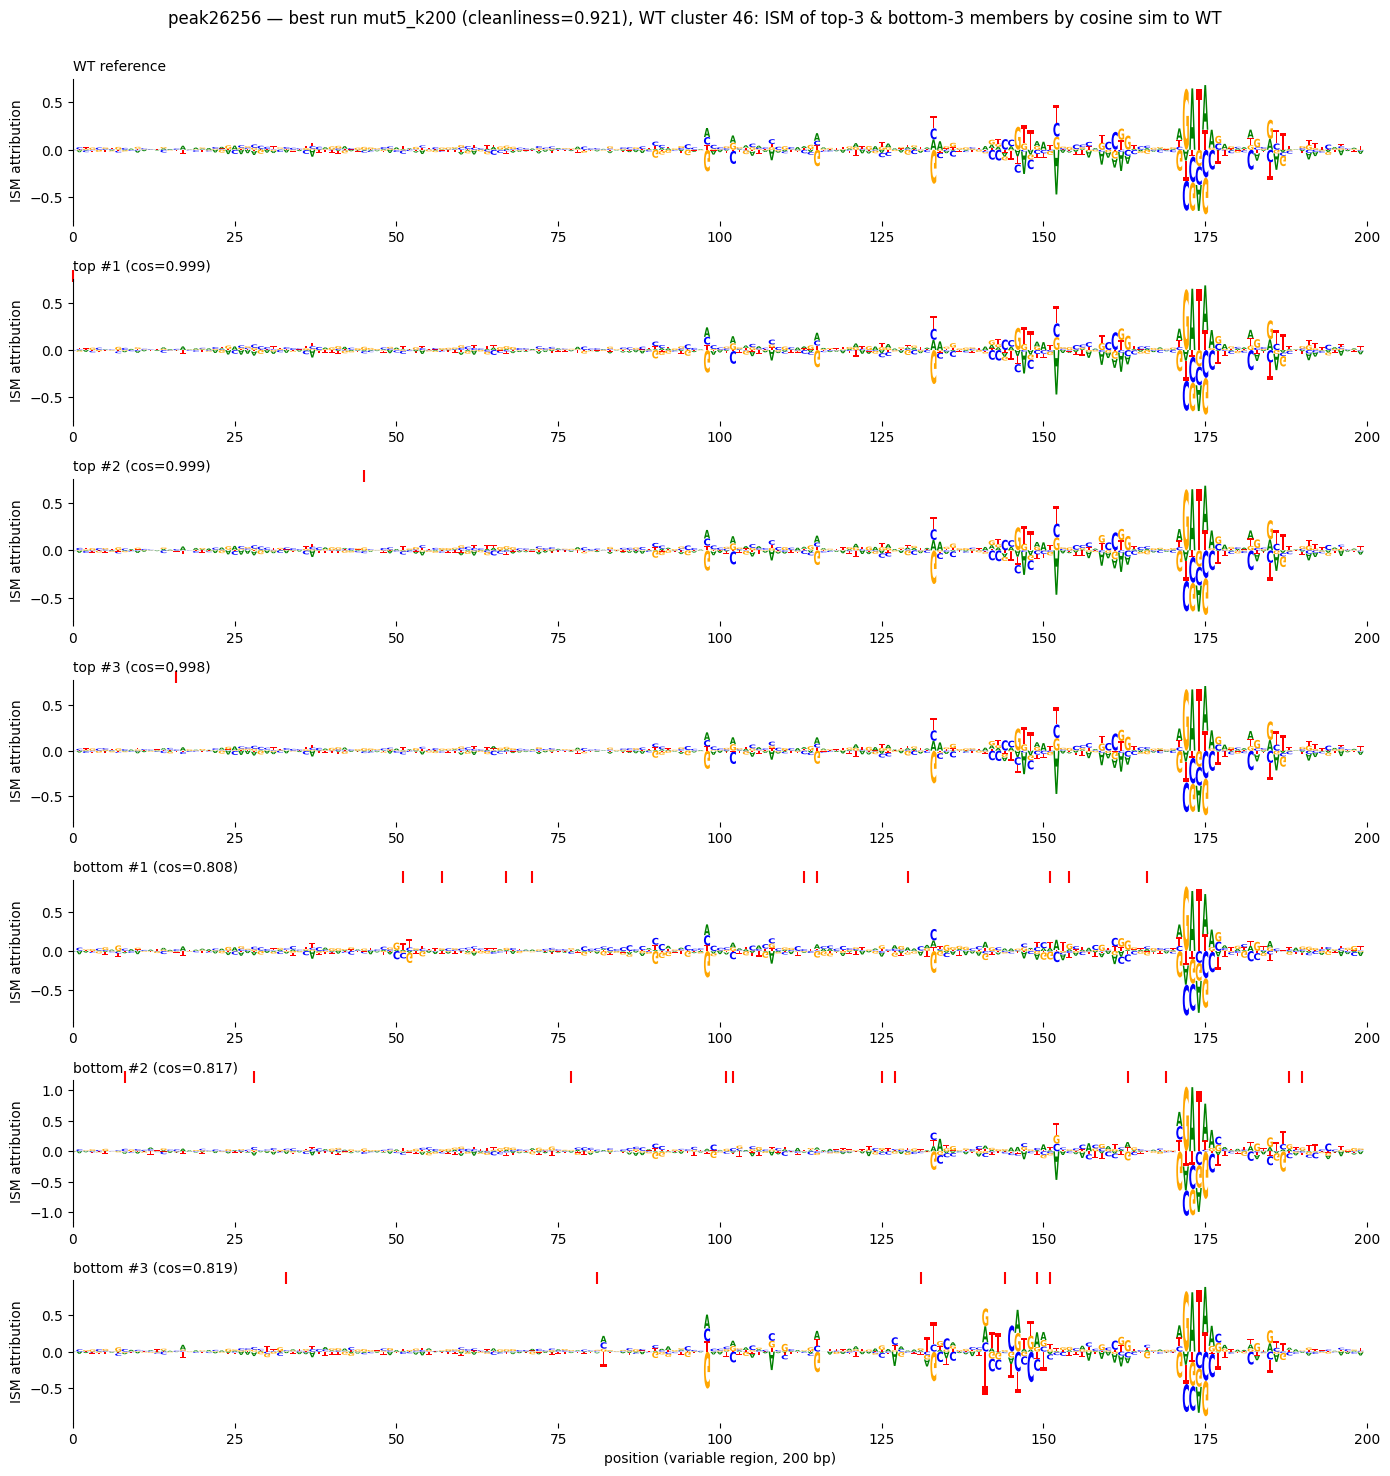

In [78]:
# FINAL: best-performing run (largest cleanliness, excluding the random baseline) ->
# ISM maps of its top-3 and bottom-3 WT-cluster members by cosine sim to WT.
best = max((d for d in results if not d["is_random"]), key=lambda d: d["cleanliness"])
suf  = lib_suffix(best["fg_name"])
ISM_H5, LIB_H5 = R / f"ism{suf}" / f"{REF_SEQ}.h5", R / f"mutagenesis_lib{suf}" / f"{REF_SEQ}.h5"
print(f"best run: {best['label']}  ({best['fg_name']}, cleanliness={best['cleanliness']:.3f})")

labels     = np.load(R / best["fg_name"] / REF_SEQ / "cluster_labels.npy")
wt_cluster = int(labels[0])                                   # WT reference = library row 0
with h5py.File(ISM_H5) as f:
    attributions = f["ism_centered"][:]                       # (N, 200, 4) ISM maps
with h5py.File(LIB_H5) as f:
    var_seqs = f["sequences"][:, 15:215, :]                   # (N, 200, 4) variable-region one-hot

wt_map     = attributions[0]                                  # WT ISM map
wt_int     = var_seqs[0].argmax(-1)                           # WT bases
is_variant = (var_seqs.argmax(-1) != wt_int).any(1)          # differs from WT (excludes idx0 + exact-WT dupes)

members = np.where(labels == wt_cluster)[0]
members = members[is_variant[members]]                        # rank variants only; WT shown separately
flat    = attributions[members].reshape(len(members), -1)
cos     = flat @ wt_map.ravel() / (np.linalg.norm(flat, axis=1) * np.linalg.norm(wt_map))
order   = np.argsort(cos)                                     # ascending: low cos = bottom

top     = members[order[-3:][::-1]]; tcos = cos[order[-3:][::-1]]   # top-3 most similar to WT
bottom  = members[order[:3]];        bcos = cos[order[:3]]          # bottom-3 least similar to WT

# (title, seq index, whether to draw red mutation ticks)
panels  = [("WT reference", 0, False)]
panels += [(f"top #{i+1} (cos={c:.3f})",    int(idx), True) for i, (idx, c) in enumerate(zip(top, tcos))]
panels += [(f"bottom #{i+1} (cos={c:.3f})", int(idx), True) for i, (idx, c) in enumerate(zip(bottom, bcos))]

# sharex=False so every logo is on its own scale
fig, axes = plt.subplots(len(panels), 1, figsize=(14, 2.1 * len(panels)), sharex=False, squeeze=False)
for ax, (title, idx, tick) in zip(axes[:, 0], panels):
    fast_logo(attributions[idx], ax)                          # raw ISM map, full 4 channels
    if tick:
        mut = np.where(var_seqs[idx].argmax(-1) != wt_int)[0] # positions mutated from WT
        ax.plot(mut, np.full(len(mut), 1.02), marker='|', linestyle='None', color='red',
                markersize=9, markeredgewidth=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel("ISM attribution")
    ax.set_xlim(0, 200)
    for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
axes[-1, 0].set_xlabel("position (variable region, 200 bp)")
fig.suptitle(f"{REF_SEQ} — best run {best['label']} (cleanliness={best['cleanliness']:.3f}), WT cluster "
             f"{wt_cluster}: ISM of top-3 & bottom-3 members by cosine sim to WT", y=1.001, fontsize=12)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_bestrun_{best['label']}_top_bottom3_ism.png", dpi=150, bbox_inches="tight")
plt.show()

# Background-subtracted variant

The SEAM maps still contain the **library-wide background** — the WT-motif backbone every
mutant shares — which is why even random clustering scored ~0.6 above. Here we redo the exact
same decomposition, but first subtract each cluster's background:

```
foreground_i = ism_i - average_background_scaled          # = ism_i - bg_scale * background
```

**Crucially, every run — real AND its matched random control — has its background computed the
same way SEAM computes a cluster's background** (entropic-position average, adaptive per-cluster
scaling), at the correct per-library mutation rate (**0.05 for mut5, 0.10 otherwise**). These
backgrounds are precomputed to `cluster_assess/results/recomputed_bg/` by
`cluster_assess/tools/run_recompute_backgrounds.sh`; for the 10% real runs they reproduce SEAM's
saved background exactly.

This fixes two earlier bugs: (a) the random control used to borrow the *real* cluster's
background — nonzero at only a few positions — so it barely removed the backbone and random
"foregrounds" still looked like motifs; (b) the mut5 background was cut at the wrong 0.10
threshold. With each run's own correct background, real clusters stay high while the random
baseline collapses toward noise.

In [ ]:
# Background-subtracted decomposition, using the RECOMPUTED per-run backgrounds
# (cluster_assess/results/recomputed_bg). EVERY run -- real AND its random control -- has its
# background cut the SAME way SEAM cuts a cluster, at the correct per-library mut_rate (0.05 mut5 /
# 0.10 else). This fixes two bugs: (a) random controls previously borrowed the REAL cluster's
# background (nonzero at only a few positions) so they barely subtracted the backbone -> random
# "foregrounds" still looked like motifs; (b) mut5 real backgrounds were cut at the wrong 0.10
# threshold. For 10% real runs the recomputed background equals SEAM's saved one exactly.
#   Precompute first:  sbatch cluster_assess/tools/run_recompute_backgrounds.sh
CACHE_BG  = OUT / f"{REF_SEQ}_decomp_bg_recomputed.pkl"
BG_ROOT   = OUT / "recomputed_bg"
RECOMPUTE = False

def _decomp_bg(r):
    labels = r.get("random_labels")
    if labels is None:
        labels = np.load(r["fg_dir"] / "cluster_labels.npy")
    wt_cluster = int(labels[0]); members = np.where(labels == wt_cluster)[0]
    with h5py.File(r["ism_h5"]) as f:
        maps = f["ism_centered"][members]                    # (M, 200, 4)
    bgdir = BG_ROOT / REF_SEQ / r["label"]                   # recomputed, correct-mut_rate background
    if not (bgdir / "average_background_scaled.npy").exists():
        raise FileNotFoundError(f"missing recomputed bg for {r['label']} -> run "
                                f"cluster_assess/tools/run_recompute_backgrounds.sh first ({bgdir})")
    bgs      = np.load(bgdir / "average_background_scaled.npy")
    bg_scale = float((bgdir / "bg_scale.txt").read_text())
    M = len(members)
    fgmaps  = (maps - bgs)
    avg_map = fgmaps.mean(0).astype(np.float32)              # FOREGROUND = avg WT-cluster map - bg
    X = fgmaps.reshape(M, -1).astype(np.float64)
    _, S, Vt = np.linalg.svd(X, full_matrices=False)
    frac = S ** 2 / np.sum(S ** 2)
    modes = [_orient(Vt[k].reshape(200, 4), avg_map) for k in range(3)]
    return dict(label=r["label"], fg_name=r["fg_name"], lib_base=r["lib_base"], lib_size=r["lib_size"],
                wt_cluster=wt_cluster, n_members=M, n_clusters=r["n_clusters"],
                cleanliness=float(frac[0]), frac=frac[:3].astype(float), modes=modes,
                avg_map=avg_map, bg_scale=bg_scale, is_random=r["fg_dir"] is None)

cache = {} if (RECOMPUTE or not CACHE_BG.exists()) else pickle.load(open(CACHE_BG, "rb"))
if isinstance(cache, list):                                  # migrate old list-format cache -> dict by label
    cache = {d["label"]: d for d in cache}

n_new = 0
for r in runs:
    if r["label"] not in cache:
        cache[r["label"]] = _decomp_bg(r); n_new += 1
        d = cache[r["label"]]
        print(f"computed {r['label']:20s}  bg_scale={d['bg_scale']:.3f}  mode1={d['cleanliness']:.3f}")
if n_new:
    pickle.dump(cache, open(CACHE_BG, "wb"))
    print(f"cached {n_new} new run(s) -> {CACHE_BG.name}")
else:
    print(f"all {len(runs)} runs loaded from cache ({CACHE_BG.name})")

results_bg = sorted((cache[r["label"]] for r in runs), key=lambda d: (d["is_random"], d["label"]))

## 1b. Cluster cleanliness (background-subtracted) across all SEAM runs

Same mode-1 fraction, computed after subtracting each run's **own** background (recomputed at the
correct per-library mut_rate: 0.05 mut5 / 0.10 else). With the correct background the random
baseline collapses to ~0.25-0.30 (its foreground is essentially noise) while real clusters stay
high — including mut5, whose random no longer floors high now that it's cut at 0.05 instead of
0.10. `bg_scale` is annotated at the base of each bar.

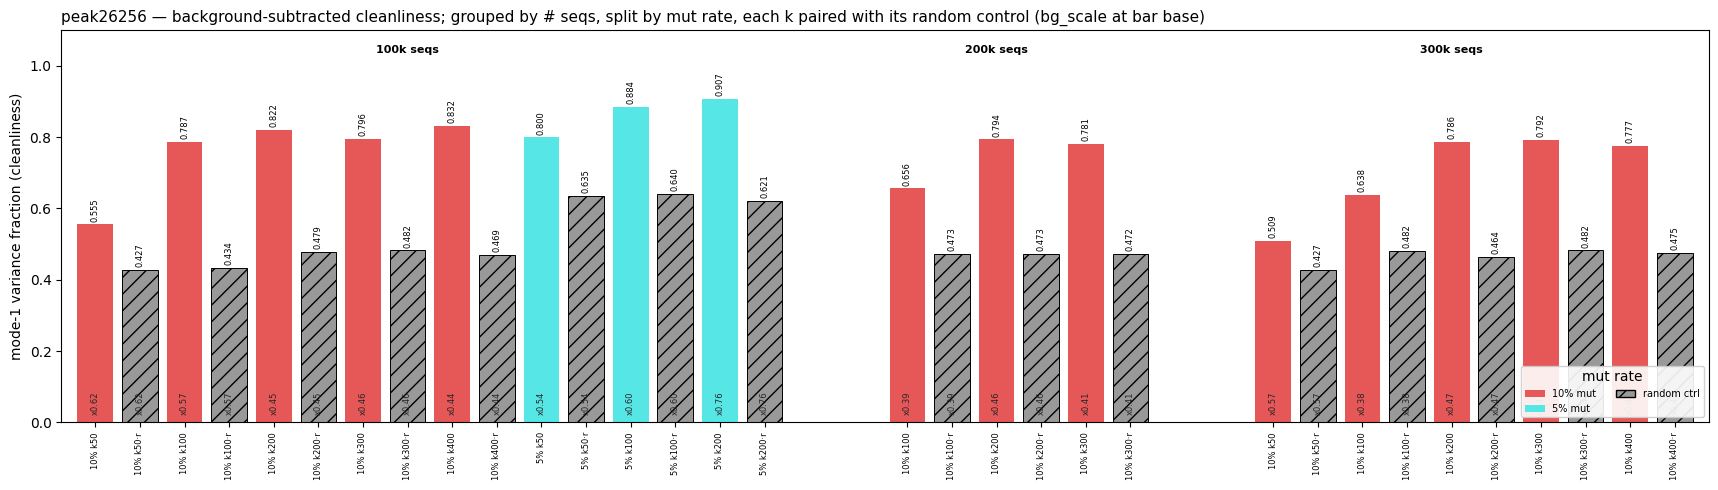

In [84]:
import colorsys
from matplotlib.patches import Patch

def kof(d):   return int(d["label"].split("_k")[-1])
def basel(d):
    lib = d["label"].split("_k")[0]
    return lib[5:] if lib.startswith("rand-") else lib
NSEQ  = {"100k": 100, "200k": 200, "300k": 300, "mut5": 100, "mut5-200k": 200, "mut5-300k": 300}
def nseq(d):  return NSEQ[basel(d)]                           # library size = number of seqs (the group)
def mrate(d): return "5%" if basel(d).startswith("mut5") else "10%"   # mutagenesis rate (split within group)
MRANK = {"10%": 0, "5%": 1}

# drop singleton intermediate cluster counts (each exists for only one library -> no comparison value)
EXCLUDE_K = {150, 250, 350}

# group by # seqs (100k/200k/300k); within a group split by mut rate, then k, each real paired with its random
order = sorted((d for d in results_bg if kof(d) not in EXCLUDE_K),
               key=lambda d: (nseq(d), MRANK[mrate(d)], kof(d), d["is_random"]))
rates  = sorted({mrate(d) for d in order}, key=lambda m: MRANK[m])
rcolor = {m: colorsys.hsv_to_rgb(i / max(len(rates), 2), 0.62, 0.90) for i, m in enumerate(rates)}
nseqs  = sorted({nseq(d) for d in order})

# x positions with a wide gap between seq-count groups
GAP = 2.2
xs, x, prev = [], 0, None
for d in order:
    if prev is not None and nseq(d) != prev: x += GAP
    xs.append(x); x += 1; prev = nseq(d)

fig, ax = plt.subplots(figsize=(max(8, 0.42 * x + 2), 5.0))
for xi, d in zip(xs, order):
    ax.bar(xi, d["cleanliness"], color="0.6" if d["is_random"] else rcolor[mrate(d)],
           hatch="//" if d["is_random"] else None,
           edgecolor="black" if d["is_random"] else "none", linewidth=0.7)
    ax.text(xi, d["cleanliness"] + 0.008, f"{d['cleanliness']:.3f}",
            ha="center", va="bottom", fontsize=6, rotation=90)
    ax.text(xi, 0.02, f"x{d['bg_scale']:.2f}", ha="center", va="bottom",
            fontsize=6, color="0.15", rotation=90)             # bg_scale at bar base

ax.set_xticks(xs)
ax.set_xticklabels([f"{mrate(d)} k{kof(d)}" + ("·r" if d["is_random"] else "") for d in order],
                   rotation=90, fontsize=6.0)
for s in nseqs:                                              # header centered over the REAL bars of each seq-count
    gx = [xi for xi, d in zip(xs, order) if not d["is_random"] and nseq(d) == s]
    ax.text(np.mean(gx), 1.03, f"{s}k seqs", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_ylabel("mode-1 variance fraction (cleanliness)")
ax.set_ylim(0, 1.10)
ax.margins(x=0.01)
ax.legend(handles=[Patch(facecolor=rcolor[m], label=f"{m} mut") for m in rates] +
                  [Patch(facecolor="0.6", edgecolor="black", hatch="//", label="random ctrl")],
          title="mut rate", fontsize=7, ncol=2, loc="lower right", framealpha=0.9)
ax.set_title(f"{REF_SEQ} — background-subtracted cleanliness; grouped by # seqs, split by mut rate, each k "
             f"paired with its random control (bg_scale at bar base)", loc="left", fontsize=11)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_cluster_cleanliness_bgsub.png", dpi=150, bbox_inches="tight")
plt.show()

## 2b. Background-subtracted logos (mode 1 + foreground)

Each real run **side by side with its matched random control** (real left, control right;
singleton k's excluded). First the bg-subtracted mode-1 consensus per run, then the
**foreground** (average WT-cluster map with background subtracted) per run.

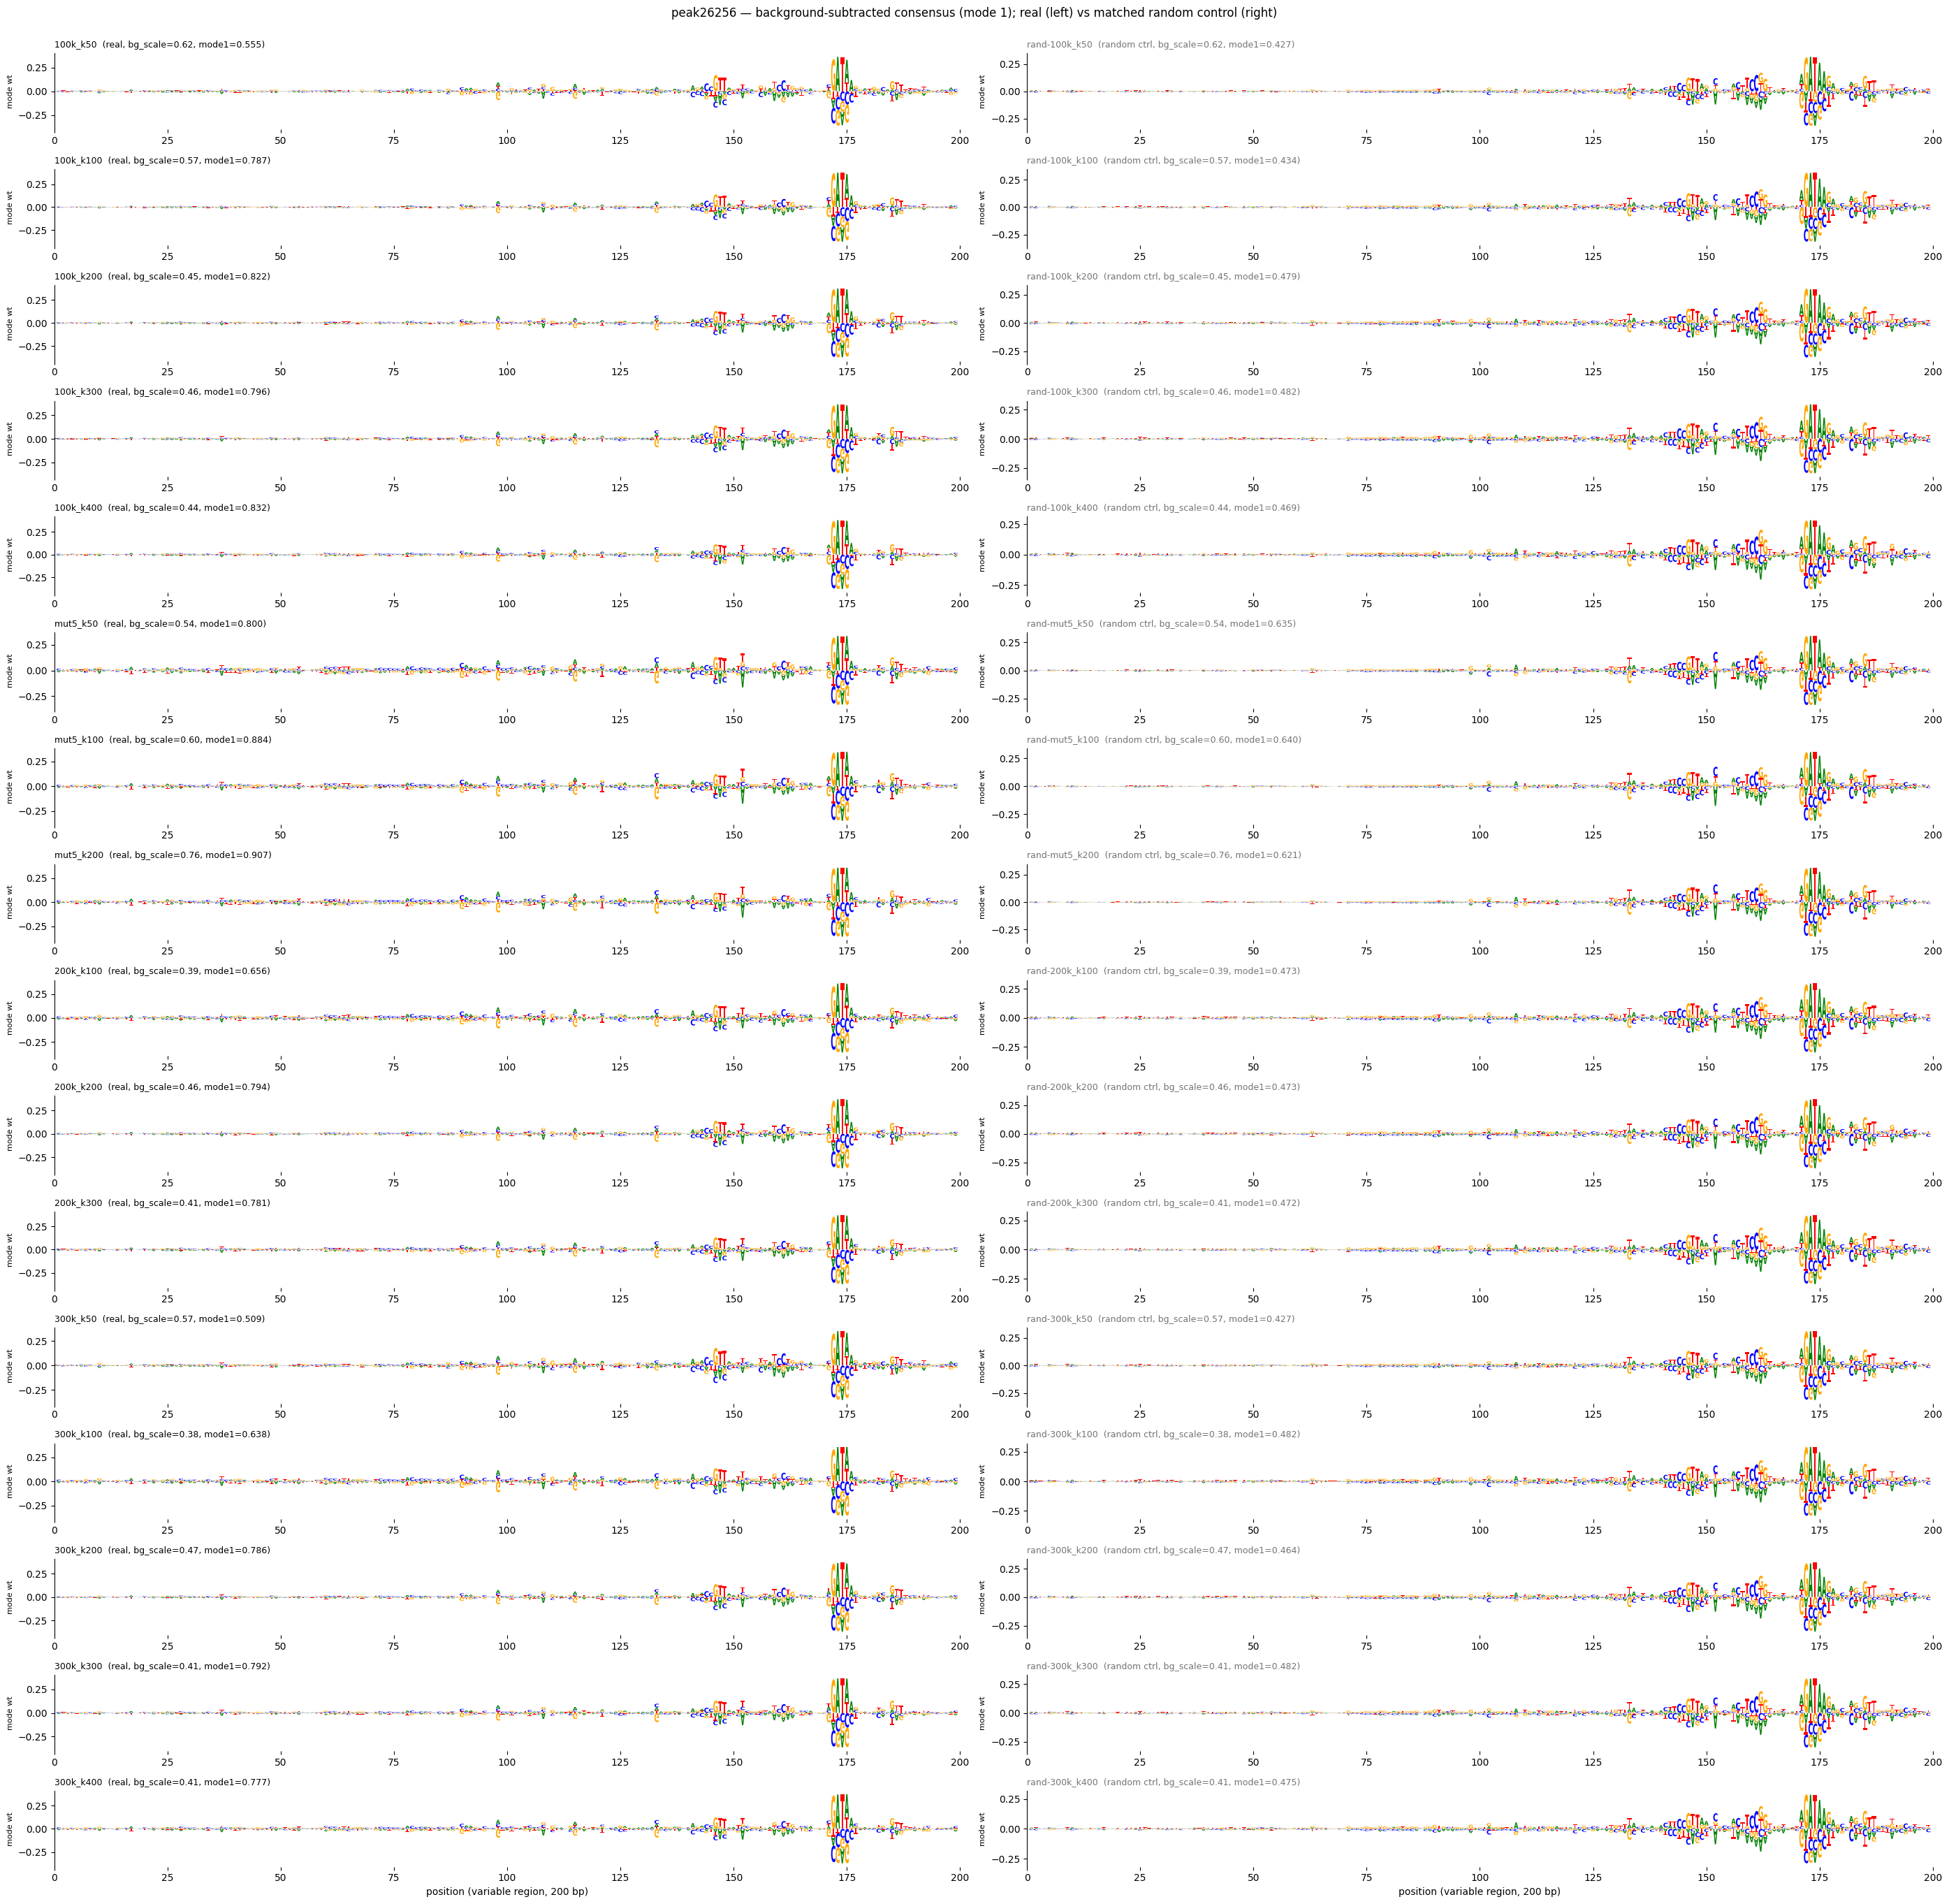

In [81]:
def kof(d):   return int(d["label"].split("_k")[-1])
def basel(d):
    lib = d["label"].split("_k")[0]
    return lib[5:] if lib.startswith("rand-") else lib
NSEQ = {"100k": 100, "200k": 200, "300k": 300, "mut5": 100, "mut5-200k": 200, "mut5-300k": 300}
EXCLUDE_K = {150, 250, 350}

# one row per real run (ordered by library size then k); real logo left, its matched random control right
bylabel = {d["label"]: d for d in results_bg}
reals   = sorted((d for d in results_bg if not d["is_random"] and kof(d) not in EXCLUDE_K),
                 key=lambda d: (NSEQ[basel(d)], basel(d), kof(d)))
pairs   = [(d, bylabel.get("rand-" + d["label"])) for d in reals]

n = len(pairs)
fig, axes = plt.subplots(n, 2, figsize=(28, 1.7 * n), sharex=False, squeeze=False)   # each on its own scale
for (dl, dr), (axL, axR) in zip(pairs, axes):
    fast_logo(dl["modes"][0], axL)                             # real bg-subtracted mode-1 eigenvector
    axL.set_title(f"{dl['label']}  (real, bg_scale={dl['bg_scale']:.2f}, mode1={dl['cleanliness']:.3f})",
                  loc="left", fontsize=9)
    if dr is not None:
        fast_logo(dr["modes"][0], axR)                         # matched random control
        axR.set_title(f"{dr['label']}  (random ctrl, bg_scale={dr['bg_scale']:.2f}, mode1={dr['cleanliness']:.3f})",
                      loc="left", fontsize=9, color="0.45")
    else:
        axR.axis("off")
    for ax in (axL, axR):
        ax.set_ylabel("mode wt", fontsize=8)
        ax.set_xlim(0, 200)
        for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("position (variable region, 200 bp)")
fig.suptitle(f"{REF_SEQ} — background-subtracted consensus (mode 1); real (left) vs matched random control (right)",
             y=1.0, fontsize=12)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_consensus_mode_logos_bgsub.png", dpi=150, bbox_inches="tight")
plt.show()

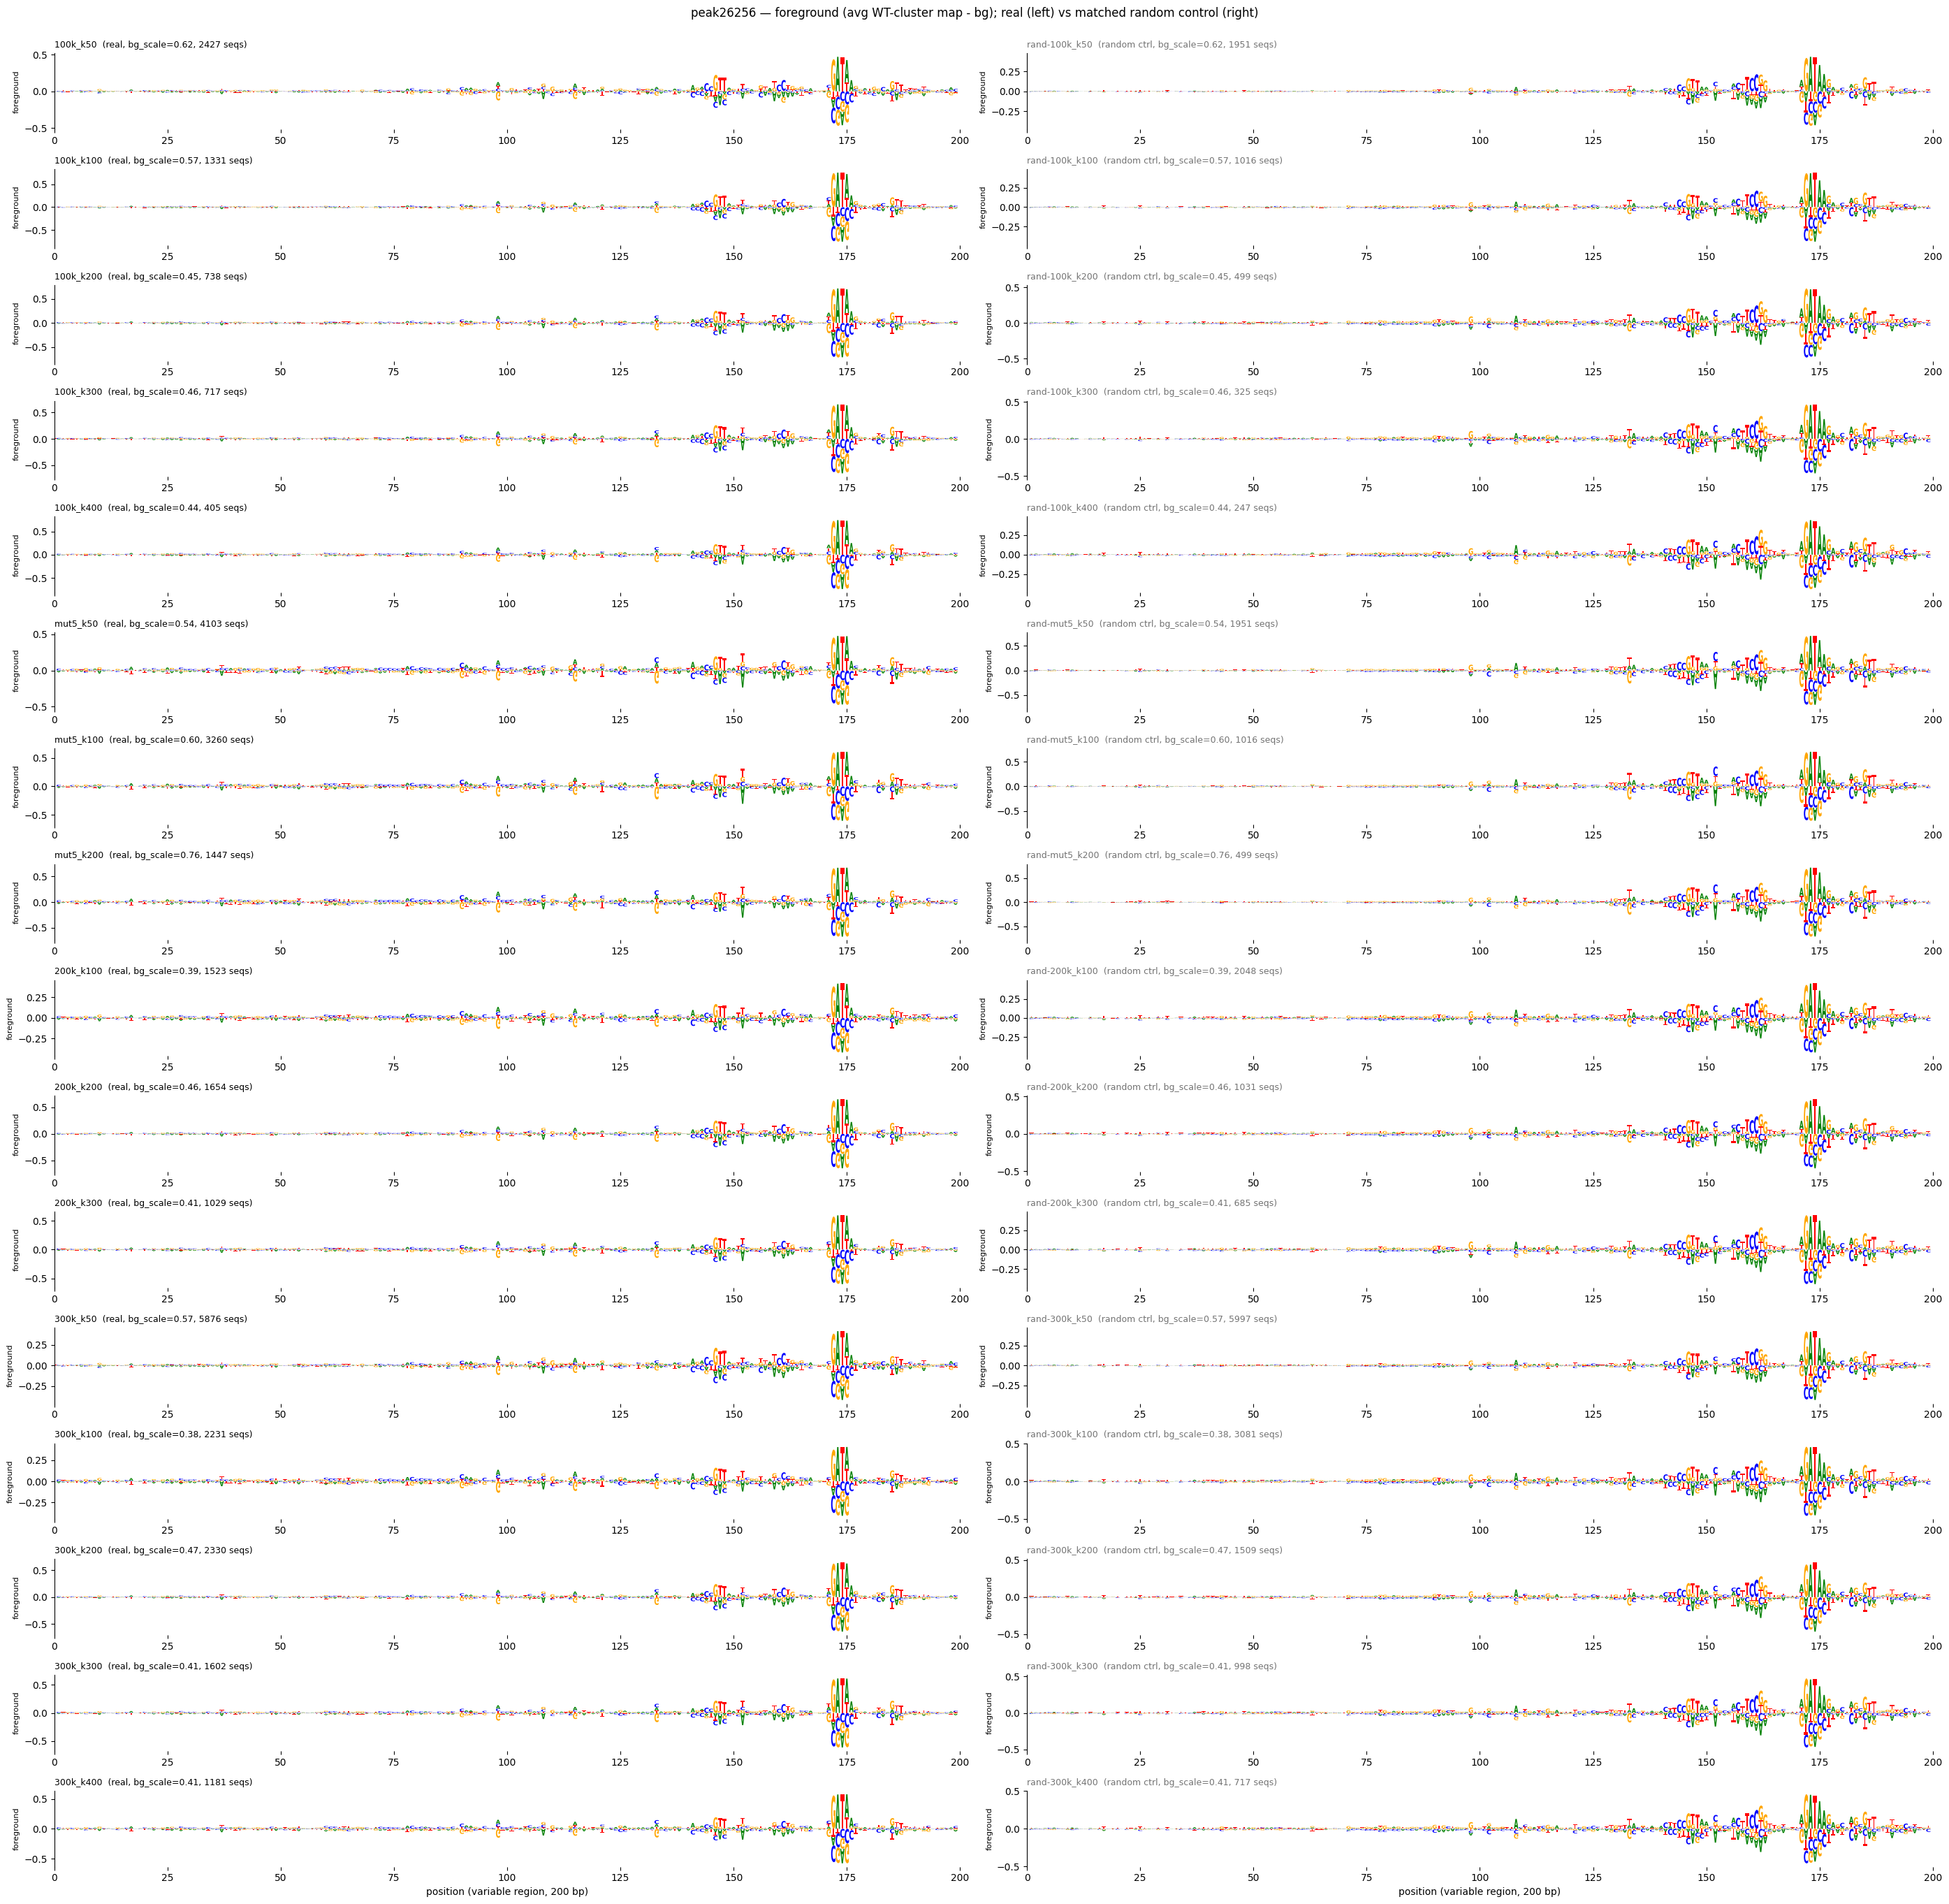

In [82]:
# per-run FOREGROUND (average WT-cluster map with background subtracted); real left, its random control right
def kof(d):   return int(d["label"].split("_k")[-1])
def basel(d):
    lib = d["label"].split("_k")[0]
    return lib[5:] if lib.startswith("rand-") else lib
NSEQ = {"100k": 100, "200k": 200, "300k": 300, "mut5": 100, "mut5-200k": 200, "mut5-300k": 300}
EXCLUDE_K = {150, 250, 350}

bylabel = {d["label"]: d for d in results_bg}
reals   = sorted((d for d in results_bg if not d["is_random"] and kof(d) not in EXCLUDE_K),
                 key=lambda d: (NSEQ[basel(d)], basel(d), kof(d)))
pairs   = [(d, bylabel.get("rand-" + d["label"])) for d in reals]

n = len(pairs)
fig, axes = plt.subplots(n, 2, figsize=(28, 1.7 * n), sharex=False, squeeze=False)   # each on its own scale
for (dl, dr), (axL, axR) in zip(pairs, axes):
    fast_logo(dl["avg_map"], axL)                             # real foreground = avg WT-cluster map - bg
    axL.set_title(f"{dl['label']}  (real, bg_scale={dl['bg_scale']:.2f}, {dl['n_members']} seqs)",
                  loc="left", fontsize=9)
    if dr is not None:
        fast_logo(dr["avg_map"], axR)                         # matched random control
        axR.set_title(f"{dr['label']}  (random ctrl, bg_scale={dr['bg_scale']:.2f}, {dr['n_members']} seqs)",
                      loc="left", fontsize=9, color="0.45")
    else:
        axR.axis("off")
    for ax in (axL, axR):
        ax.set_ylabel("foreground", fontsize=8)
        ax.set_xlim(0, 200)
        for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("position (variable region, 200 bp)")
fig.suptitle(f"{REF_SEQ} — foreground (avg WT-cluster map - bg); real (left) vs matched random control (right)",
             y=1.0, fontsize=12)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_foreground_logos.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# FINAL (bg-subtracted, CORRECTED backgrounds): best run by bg-subtracted cleanliness.
# LEFT = real WT cluster; RIGHT = its matched RANDOM control. Each column subtracts its OWN
# recomputed background (real: SEAM-equivalent at the right mut_rate; random: the random subset's
# own background) -> the random column should now look like NOISE, not a motif.
best = max((d for d in results_bg if not d["is_random"]), key=lambda d: d["cleanliness"])
suf  = lib_suffix(best["fg_name"])
ISM_H5, LIB_H5 = R / f"ism{suf}" / f"{REF_SEQ}.h5", R / f"mutagenesis_lib{suf}" / f"{REF_SEQ}.h5"
print(f"best bg-subtracted run: {best['label']}  bg_scale={best['bg_scale']:.3f}  cleanliness={best['cleanliness']:.3f}")

labels  = np.load(R / best["fg_name"] / REF_SEQ / "cluster_labels.npy")           # real k-means labels
rand    = next(r for r in runs if r["label"] == "rand-" + best["label"])
rlabels = rand["random_labels"]                              # random labels for the SAME library (seed=K)
with h5py.File(ISM_H5) as f:
    attributions = f["ism_centered"][:]                       # (N, 200, 4)
with h5py.File(LIB_H5) as f:
    var_seqs = f["sequences"][:, 15:215, :]                   # (N, 200, 4)
wt_int = var_seqs[0].argmax(-1)
is_variant = (var_seqs.argmax(-1) != wt_int).any(1)

def load_scaled_bg(label):                                   # recomputed correct-mut_rate scaled background
    return np.load(OUT / "recomputed_bg" / REF_SEQ / label / "average_background_scaled.npy")

def top_bottom_panels(lab, bg):                             # rank a cluster's members by cosine to its WT foreground
    fg = attributions - bg
    wt_fg = fg[0]
    wt_cl = int(lab[0]); members = np.where(lab == wt_cl)[0]; members = members[is_variant[members]]
    flat = fg[members].reshape(len(members), -1)
    cos  = flat @ wt_fg.ravel() / (np.linalg.norm(flat, axis=1) * np.linalg.norm(wt_fg))
    order = np.argsort(cos)
    top = members[order[-3:][::-1]]; tcos = cos[order[-3:][::-1]]     # top-3 most similar to WT
    bottom = members[order[:10]];    bcos = cos[order[:10]]           # bottom-10 least similar to WT
    panels  = [("WT foreground", 0, False)]
    panels += [(f"top #{i+1} (cos={c:.3f})",    int(idx), True) for i, (idx, c) in enumerate(zip(top, tcos))]
    panels += [(f"bottom #{i+1} (cos={c:.3f})", int(idx), True) for i, (idx, c) in enumerate(zip(bottom, bcos))]
    return wt_cl, panels, fg

real_bg = load_scaled_bg(best["label"]); rand_bg = load_scaled_bg("rand-" + best["label"])
wt_cluster, panels_real, fg_real = top_bottom_panels(labels,  real_bg)     # real column: own background
rand_wt,    panels_rand, fg_rand = top_bottom_panels(rlabels, rand_bg)     # random column: own background
cols = [("real", panels_real, fg_real), ("random ctrl", panels_rand, fg_rand)]
nrow = max(len(panels_real), len(panels_rand))

# sharex=False so every logo is on its own scale
fig, axes = plt.subplots(nrow, 2, figsize=(28, 2.1 * nrow), sharex=False, squeeze=False)
for c, (tag, panels, fg) in enumerate(cols):
    for rr in range(nrow):
        ax = axes[rr, c]
        if rr >= len(panels):
            ax.axis("off"); continue
        title, idx, tick = panels[rr]
        fast_logo(fg[idx], ax)                                # background-subtracted map, full 4 channels
        if tick:
            mut = np.where(var_seqs[idx].argmax(-1) != wt_int)[0]
            ax.plot(mut, np.full(len(mut), 1.02), marker='|', linestyle='None', color='red',
                    markersize=9, markeredgewidth=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
        head = f"[{tag}] " if rr == 0 else ""
        ax.set_title(head + title, loc="left", fontsize=10, color="0.45" if tag == "random ctrl" else "black")
        ax.set_ylabel("fg attribution")
        ax.set_xlim(0, 200)
        for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
axes[-1, 0].set_xlabel("position (variable region, 200 bp)")
axes[-1, 1].set_xlabel("position (variable region, 200 bp)")
fig.suptitle(f"{REF_SEQ} — best bg-subtracted run {best['label']} (bg_scale={best['bg_scale']:.2f}): "
             f"real WT cluster {wt_cluster} (left) vs random control {rand_wt} (right); each subtracts its own "
             f"correct-mut_rate background", y=1.001, fontsize=12)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_bestrun_bgsub_{best['label']}_real_vs_random_top3_bottom10.png", dpi=150, bbox_inches="tight")
plt.show()